In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [2]:
input_dim = 784
hidden_dim = 400
latent_dim = 20
batch_size = 128
epochs = 10
learning_rate = 0.001

In [3]:
transform = transforms.ToTensor()

train_data = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_data = datasets.MNIST("./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print("Training samples:", len(train_data))
print("Test samples:", len(test_data))

100%|██████████| 9.91M/9.91M [00:00<00:00, 36.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 931kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 7.78MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.4MB/s]

Training samples: 60000
Test samples: 10000


In [4]:
import torch.nn as nn
import torch

class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )

        self.mu = nn.Linear(hidden_dim, latent_dim)
        self.log_var = nn.Linear(hidden_dim, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.mu(h), self.log_var(h)

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        return self.decode(z), mu, log_var


model = VAE(input_dim, hidden_dim, latent_dim).to(device)
print(model)

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=400, bias=True)
    (1): ReLU()
  )
  (mu): Linear(in_features=400, out_features=20, bias=True)
  (log_var): Linear(in_features=400, out_features=20, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=20, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=784, bias=True)
    (3): Sigmoid()
  )
)


In [5]:
import torch.nn.functional as F
import torch

def vae_loss(x_recon, x, mu, log_var):
    recon_loss = F.binary_cross_entropy(x_recon, x, reduction="sum") / x.size(0)

    kl_loss = -0.5 * torch.sum(1 + log_var - mu**2 - torch.exp(log_var)) / x.size(0)

    total_loss = recon_loss + kl_loss

    return total_loss, recon_loss, kl_loss

In [6]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=learning_rate)

history = {"total": [], "recon": [], "kl": []}

for epoch in range(epochs):
    model.train()

    total_loss_sum = 0
    recon_loss_sum = 0
    kl_loss_sum = 0

    for images, _ in train_loader:
        images = images.view(-1, input_dim).to(device)

        x_recon, mu, log_var = model(images)

        loss, recon_loss, kl_loss = vae_loss(x_recon, images, mu, log_var)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss_sum += loss.item()
        recon_loss_sum += recon_loss.item()
        kl_loss_sum += kl_loss.item()

    n = len(train_loader)

    history["total"].append(total_loss_sum / n)
    history["recon"].append(recon_loss_sum / n)
    history["kl"].append(kl_loss_sum / n)

    print("Epoch", epoch+1,
          "| Total:", history["total"][-1],
          "| Recon:", history["recon"][-1],
          "| KL:", history["kl"][-1])

print("Training done")

Epoch 1 | Total: 165.68100139886332 | Recon: 150.37787961654826 | KL: 15.303121784316705
Epoch 2 | Total: 121.79801226780613 | Recon: 99.11208750190004 | KL: 22.685924839109244
Epoch 3 | Total: 114.8708316176685 | Recon: 90.52695567572295 | KL: 24.343875885009766
Epoch 4 | Total: 111.99205882513701 | Recon: 87.13810404633153 | KL: 24.853954709669168
Epoch 5 | Total: 110.16106260254948 | Recon: 85.03313008452784 | KL: 25.12793255055637
Epoch 6 | Total: 109.02007729666573 | Recon: 83.72504797571503 | KL: 25.295029207079143
Epoch 7 | Total: 108.15739722343396 | Recon: 82.76474687133008 | KL: 25.392650327702828
Epoch 8 | Total: 107.5125936577315 | Recon: 82.0414367220295 | KL: 25.47115702110567
Epoch 9 | Total: 106.93330980313104 | Recon: 81.4414265191377 | KL: 25.491883109119147
Epoch 10 | Total: 106.49892732990322 | Recon: 80.96903023790958 | KL: 25.529897340070974
Training done


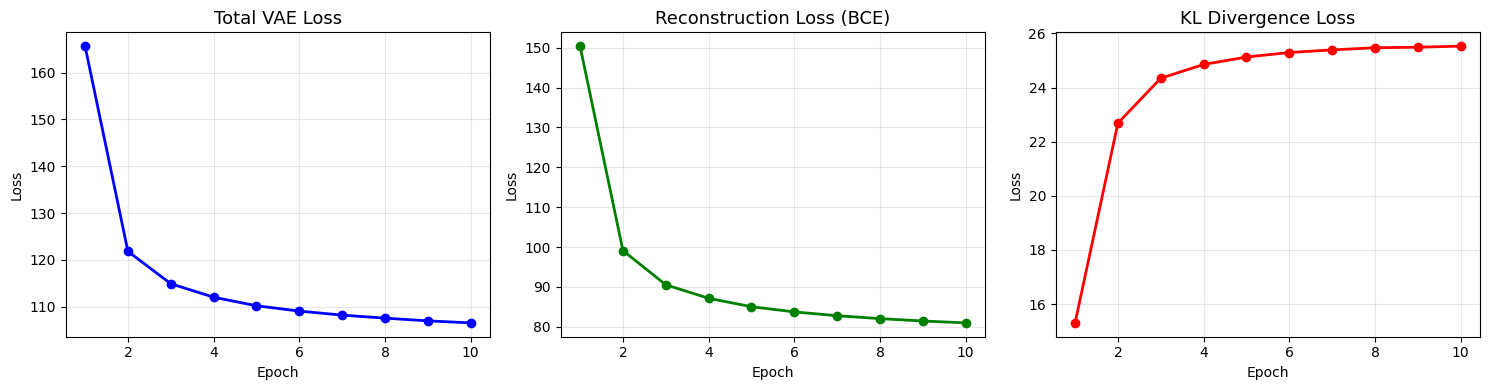

Loss curves saved to loss_curves.png


In [8]:
epochs_range = range(1, epochs + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_range, history["total"], "b-o", linewidth=2)
axes[0].set_title("Total VAE Loss", fontsize=13)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")

axes[1].plot(epochs_range, history["recon"], "g-o", linewidth=2)
axes[1].set_title("Reconstruction Loss (BCE)", fontsize=13)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")

axes[2].plot(epochs_range, history["kl"], "r-o", linewidth=2)
axes[2].set_title("KL Divergence Loss", fontsize=13)
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Loss")

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("loss_curves.png", dpi=120)
plt.show()
print("Loss curves saved to loss_curves.png")

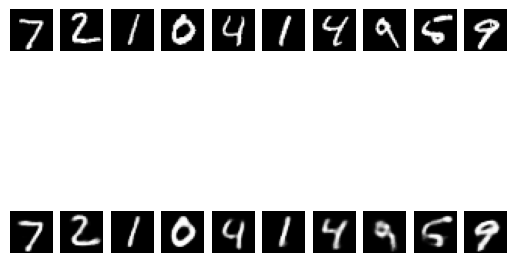

In [9]:
model.eval()

with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.view(-1, input_dim).to(device)

    recon, _, _ = model(images)

n = 10
fig, axes = plt.subplots(2, n)

for i in range(n):
    axes[0, i].imshow(images[i].cpu().view(28, 28), cmap="gray")
    axes[0, i].axis("off")

    axes[1, i].imshow(recon[i].cpu().view(28, 28), cmap="gray")
    axes[1, i].axis("off")

plt.show()

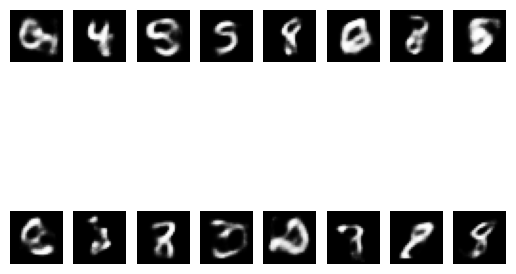

In [10]:
model.eval()

with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    generated = model.decode(z)

fig, axes = plt.subplots(2, 8)

for i in range(16):
    axes[i//8, i%8].imshow(generated[i].cpu().view(28, 28), cmap="gray")
    axes[i//8, i%8].axis("off")

plt.show()

## Interpretation

Variational Autoencoder (VAE) on the MNIST dataset to learn how to compress, reconstruct, and generate handwritten digit images. The model takes grayscale images of size 28×28 pixels, flattens them into 784-dimensional vectors, and passes them through an encoder network that produces two outputs: the mean (μ) and log variance (log σ²), representing a probability distribution in a lower-dimensional latent space. Instead of directly sampling from this distribution, the model uses the reparameterization trick, where a latent vector z is computed as z = μ + σ·ε (with ε sampled from a standard normal distribution), allowing gradients to flow during training. This latent vector is then passed through a decoder network to reconstruct the original image. The model is trained using a combination of reconstruction loss (Binary Cross Entropy), which ensures the output image is similar to the input, and KL divergence, which regularizes the latent space to follow a standard normal distribution. During training, the model learns meaningful patterns in the data, enabling it not only to reconstruct input images but also to generate entirely new digit images by sampling random vectors from the latent space. Overall, this project demonstrates how probabilistic deep learning models can perform both data compression and data generation effectively.